In [2]:
import pandas as pd
import numpy as np

panel_df = pd.read_csv(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\raw\nifty100_panel.csv")

panel_df["Date"] = pd.to_datetime(panel_df["Date"])

In [3]:
monthly_df = (
    panel_df
    .set_index("Date")
    .groupby("Ticker")
    .resample("ME")
    .last()
    .reset_index()
)

In [4]:
monthly_df[
    monthly_df["Ticker"] == "RELIANCE.NS"
].head(15)

,Ticker,Date,Open,High,Low,Close,Volume
7842,RELIANCE.NS,2015-01-31,198.092794,198.359055,193.619731,194.951004,21746801.0
7843,RELIANCE.NS,2015-02-28,180.530723,183.395617,179.902368,182.234741,18659378.0
7844,RELIANCE.NS,2015-03-31,174.236443,177.410197,174.236443,175.940475,20235395.0
7845,RELIANCE.NS,2015-04-30,181.052568,184.439319,180.615910,183.683151,34802149.0
7846,RELIANCE.NS,2015-05-31,189.782684,191.195434,188.316013,189.157196,29277517.0
7847,RELIANCE.NS,2015-06-30,213.508238,216.301373,213.098430,215.708237,23184864.0
7848,RELIANCE.NS,2015-07-31,215.686670,217.390604,213.529807,216.085693,16634259.0
7849,RELIANCE.NS,2015-08-31,188.262086,188.262086,184.153258,184.606201,20708942.0
7850,RELIANCE.NS,2015-09-30,183.549386,186.525849,180.853292,185.986633,17292020.0
7851,RELIANCE.NS,2015-10-31,203.198441,206.174920,202.767080,204.406296,13366359.0


In [5]:
monthly_df.shape

(10787, 7)

In [6]:
monthly_df["target_return"] = (
    monthly_df
    .groupby("Ticker")["Close"]
    .shift(-1)
    / monthly_df["Close"]
    - 1
)

In [7]:
monthly_df = monthly_df.dropna(
    subset=["target_return"]
)

In [8]:
monthly_df.head()

,Ticker,Date,Open,High,Low,Close,Volume,target_return
0,ABB.NS,2015-01-31,1139.952330,1142.549087,1101.867345,1111.302002,45507.0,0.097944
1,ABB.NS,2015-02-28,1202.446521,1224.691669,1202.446521,1220.147461,150537.0,-0.106090
2,ABB.NS,2015-03-31,1056.079096,1097.886049,1052.530319,1090.701904,93726.0,0.063402
3,ABB.NS,2015-04-30,1162.589962,1166.931237,1141.925538,1159.854980,64960.0,0.000187
4,ABB.NS,2015-05-31,1176.395172,1179.651070,1155.904463,1160.072021,19747.0,-0.008832


In [9]:
monthly_df["target_return"].describe()

count    10690.000000
mean         0.019392
std          0.104007
min         -0.637599
25%         -0.039654
50%          0.013453
75%          0.071487
max          1.408602
Name: target_return, dtype: float64

<Axes: >

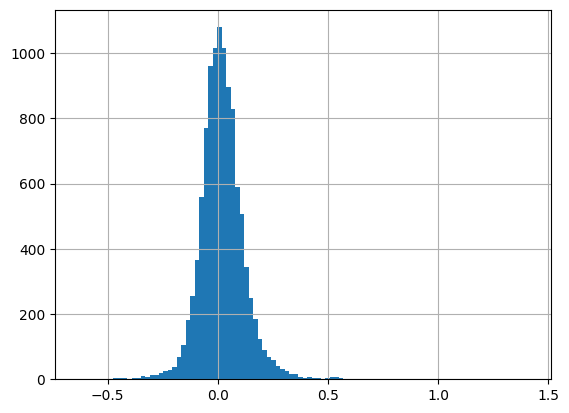

In [10]:
monthly_df["target_return"].hist(
    bins=100
)

In [12]:
monthly_df.to_csv(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\raw\nifty100_monthly.csv")